<center>

# **Primera pueba de MLP**

</center>


---

**Autor**: Isaac Yael Cantú Fernández

**Fecha**: 04/2026

In [156]:
import pandas as pd
import yaml
import numpy as np
from pprint import pprint
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import TensorDataset
import torch

df_particles= pd.read_csv("/home/icantu24/Documents/corsario/dat_files/corsario_5000.csv")
df_shower = pd.read_csv("/home/icantu24/Documents/corsario/dat_files/shower_corsario_5000.csv")

### **2.1 Cargar datos**

> **GRID de datos**

In [76]:

GRID = 8

features = ["x","y","energy","t"]

# rangos espaciales
x_bins = np.linspace(df_particles["x"].min(), df_particles["x"].max(), GRID+1)
y_bins = np.linspace(df_particles["y"].min(), df_particles["y"].max(), GRID+1)


def build_tensor(shower_particles):

    tensor = np.zeros((GRID, GRID, 5))

    for i in range(GRID):
        for j in range(GRID):

            mask = (
                (shower_particles["x"] >= x_bins[i]) &
                (shower_particles["x"] < x_bins[i+1]) &
                (shower_particles["y"] >= y_bins[j]) &
                (shower_particles["y"] < y_bins[j+1])
            )

            cell = shower_particles[mask]

            if len(cell) > 0:

                energies = cell["energy"].values
                times = cell["t"].values

                tensor[i,j,0] = len(cell)                # conteo
                tensor[i,j,1] = energies.sum()           # energía total
                tensor[i,j,2] = energies.mean()          # energía media
                tensor[i,j,3] = energies.std()           # std energía
                tensor[i,j,4] = times.mean()             # tiempo medio

    return tensor

X = []
y = []

for shower_id, group in df_particles.groupby("shower"):

    tensor = build_tensor(group)

    X.append(tensor)

    energy = df_shower.loc[
        df_shower["event_no"] == int(shower_id),
        "total_energy"
    ].values[0]

    y.append(energy)

X = np.array(X)
y = np.array(y)

print("Shape X:", X.shape)
print("Shape y:", y.shape)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

X = (X - X.mean()) / (X.std() + 1e-8)
y = np.log1p(y)

class ShowerDataset(Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        grid = self.X[idx].reshape(-1)#.permute(2,0,1)  # (channels,8,8)
        target = self.y[idx]

        return grid, target

from torch.utils.data import DataLoader, random_split

dataset = ShowerDataset(X,y)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset,[train_size,val_size])

train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=32)


Shape X: (4977, 8, 8, 5)
Shape y: (4977,)


/tmp/ipykernel_6284/4084227416.py:65: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y = np.log1p(y)


/tmp/ipykernel_6284/2553220560.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.plot(np.log1p(y))


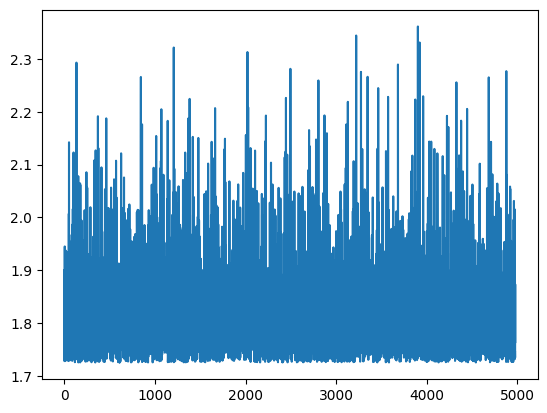

In [77]:
plt.plot(np.log1p(y))

# l

In [133]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

def grid_generator_fast(n=8, df_particles=None, df_shower=None):
    # 1. Orden consistente de showers
    showers = np.sort(df_particles["shower"].unique())
    n_showers = len(showers)
    shower_to_idx = {sh: i for i, sh in enumerate(showers)}

    # 2. Bins globales
    x_bins = np.linspace(df_particles["x"].min(), df_particles["x"].max(), n+1)
    y_bins = np.linspace(df_particles["y"].min(), df_particles["y"].max(), n+1)

    df = df_particles.copy()

    # 3. Asignación de índices (digitize)
    df["ix"] = np.digitize(df["x"], x_bins) - 1
    df["iy"] = np.digitize(df["y"], y_bins) - 1

    # Limitar índices para evitar desbordamiento en el borde superior
    df["ix"] = df["ix"].clip(0, n-1)
    df["iy"] = df["iy"].clip(0, n-1)

    # 4. Agrupación y Estadísticas
    grouped = df.groupby(["shower", "ix", "iy"])
    stats = grouped.agg(
        count=("energy", "size"),
        energy_sum=("energy", "sum"),
        energy_mean=("energy", "mean"),
        energy_std=("energy", "std"),
        time_mean=("t", "mean")
    ).reset_index()

    # 5. Creación del Tensor (CAMBIO CLAVE: forma (n, n, 5) para coincidir con tu MLP original)
    grid = np.zeros((n_showers, n, n, 5), dtype=np.float32)

    # Llenado eficiente
    # Convertimos los IDs de shower a sus índices correspondientes
    stats['s_idx'] = stats['shower'].map(shower_to_idx)
    
    # Asignación masiva (puedes usar un loop si stats no es gigantesco, 
    # pero aquí mantenemos la estructura de tu versión fast corregida)
    for row in stats.itertuples(index=False):
        # row: [shower, ix, iy, count, sum, mean, std, t_mean, s_idx]
        grid[row.s_idx, int(row.ix), int(row.iy), :] = [
            row.count,
            row.energy_sum,
            row.energy_mean,
            0 if np.isnan(row.energy_std) else row.energy_std,
            row.time_mean
        ]

    # 6. Alineación de etiquetas (Y)
    df_shower_aligned = df_shower.set_index("event_no").loc[showers]
    y = np.log1p(df_shower_aligned["total_energy"].values)

    # Retornamos el tensor aplanado de forma consistente (Showers, Features_Aplanadas)
    return grid.reshape(n_showers, -1), y

# --- Preparación de datos ---

input_data, output_data = grid_generator_fast(n=8, df_particles=df_particles, df_shower=df_shower)

def split_data(X, y, train=70, test=15, val=15, seed=42):
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, train_size=train/100, random_state=seed, shuffle=True
    )
    
    # Split restante para test y val
    rel_test_size = test / (test + val)
    X_test, X_val, y_test, y_val = train_test_split(
        X_temp, y_temp, train_size=rel_test_size, random_state=seed, shuffle=True
    )

    # Normalización (Importante: fit solo en Train)
    mean = X_train.mean()
    std = X_train.std(axis=0) + 1e-8

    X_train = (X_train - mean) / std
    X_val = (X_val - mean) / std
    X_test = (X_test - mean) / std

    # Conversión a tensores de PyTorch
    to_tensor = lambda x: torch.tensor(x, dtype=torch.float32)

    # Asegúrate de que y no se esté logueando dos veces
    # Si grid_generator_fast ya devolvió np.log1p(y), aquí ya no lo toques
    train_dataset = TensorDataset(to_tensor(X_train), to_tensor(y_train).unsqueeze(1))
    val_dataset   = TensorDataset(to_tensor(X_val), to_tensor(y_val).unsqueeze(1))
    test_dataset  = TensorDataset(to_tensor(X_test), to_tensor(y_test).unsqueeze(1))

    return train_dataset, val_dataset, test_dataset

train_dataset, val_dataset, test_dataset = split_data(X=input_data, y=output_data)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

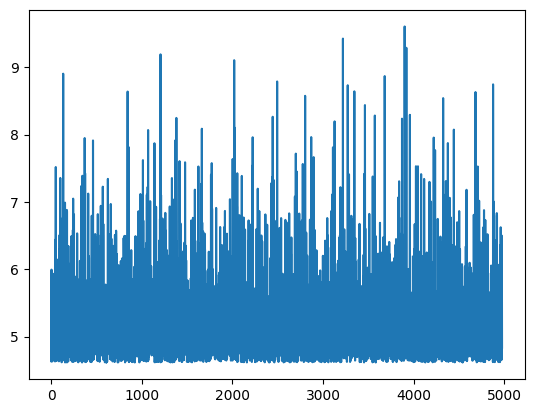

In [134]:
plt.plot(output_data)


In [158]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# ─────────────────────────────────────────────
# 1. CONSTRUCCIÓN DE LA GRILLA
# ─────────────────────────────────────────────

def grid_generator_fast(n=8, df_particles=None, df_shower=None):
    # Orden de showers reproducible para que el target quede alineado
    showers = np.sort(df_particles["shower"].unique())
    n_showers = len(showers)

    df = df_particles.copy()

    # Bug 3 ✓ — centrar ANTES de calcular los bins
    df["x"] = df.groupby("shower")["x"].transform(lambda x: x - x.mean())
    df["y"] = df.groupby("shower")["y"].transform(lambda y: y - y.mean())

    # Bins sobre coordenadas ya centradas
    x_bins = np.linspace(df["x"].min(), df["x"].max(), n + 1)
    y_bins = np.linspace(df["y"].min(), df["y"].max(), n + 1)

    df["ix"] = np.digitize(df["x"], x_bins) - 1
    df["iy"] = np.digitize(df["y"], y_bins) - 1

    # Eliminar partículas fuera de rango (borde superior de np.digitize)
    df = df[
        (df["ix"] >= 0) & (df["ix"] < n) &
        (df["iy"] >= 0) & (df["iy"] < n)
    ]

    grouped = df.groupby(["shower", "ix", "iy"])
    stats = grouped.agg(
        count       = ("energy", "size"),
        energy_sum  = ("energy", "sum"),
        energy_mean = ("energy", "mean"),
        energy_std  = ("energy", "std"),
        time_mean   = ("t",      "mean"),
    ).reset_index()

    # Bug shape ✓ — (n_showers, 5, n, n): canales primero para que el reshape
    # serialice correctamente como [canal_0_celda_0, canal_0_celda_1, ...]
    grid = np.zeros((n_showers, 5, n, n), dtype=np.float32)
    shower_to_idx = {sh: i for i, sh in enumerate(showers)}

    for _, row in stats.iterrows():
        i = shower_to_idx[row["shower"]]
        j = int(row["ix"])
        k = int(row["iy"])
        # Bug shape ✓ — grid[i, :, j, k] selecciona los 5 canales correctamente
        grid[i, :, j, k] = [
            row["count"],
            row["energy_sum"],
            row["energy_mean"],
            row["energy_std"] if not np.isnan(row["energy_std"]) else 0.0,
            row["time_mean"],
        ]

    # Bug alineamiento ✓ — reordenar df_shower según el mismo orden de showers
    # para garantizar que grid[i] corresponde a total_energy[i]
    shower_df = df_shower.set_index("event_no")
    total_energy = np.array(
        [shower_df.loc[int(sh), "total_energy"] for sh in showers],
        dtype=np.float32,
    )

    # Aplanar manteniendo orden (n_showers, 5*n*n)
    X = grid.reshape(n_showers, 5 * n * n)

    return X, total_energy


# ─────────────────────────────────────────────
# 2. SPLIT Y NORMALIZACIÓN
# ─────────────────────────────────────────────

def split_data(
    X: np.ndarray,
    y: np.ndarray,
    train: int = 70,
    test:  int = 15,
    val:   int = 15,
    seed:  int = 42,
):
    if train + test + val != 100:
        raise ValueError("Los splits deben sumar 100")

    # Split 1: train vs temp
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y,
        train_size=train / 100,
        shuffle=True,
        random_state=seed,
    )

    # Split 2: val vs test
    split = test / (test + val)
    X_test, X_val, y_test, y_val = train_test_split(
        X_temp, y_temp,
        train_size=split,
        shuffle=True,
        random_state=seed,
    )

    # Normalización usando SOLO estadísticas de train
    X_mean = X_train.mean(axis=0)   # por feature, no escalar global
    X_std  = X_train.std(axis=0) + 1e-8

    X_train_norm = (X_train - X_mean) / X_std
    X_val_norm   = (X_val   - X_mean) / X_std  # Bug 1 ✓ — nombres distintos
    X_test_norm  = (X_test  - X_mean) / X_std  # Bug 1 ✓

    def to_tensor(arr):
        return torch.tensor(arr, dtype=torch.float32)

    train_dataset = TensorDataset(to_tensor(X_train_norm), to_tensor(y_train))
    val_dataset   = TensorDataset(to_tensor(X_val_norm),   to_tensor(y_val))
    test_dataset  = TensorDataset(to_tensor(X_test_norm),  to_tensor(y_test))  # Bug 2 ✓

    # Guardar scaler correctamente para poder invertir la normalización luego
    scaler = StandardScaler()
    scaler.mean_  = X_mean
    scaler.scale_ = X_std
    scaler.n_features_in_ = X_train.shape[1]

    return train_dataset, val_dataset, test_dataset, scaler


# ─────────────────────────────────────────────
# 3. PIPELINE COMPLETO
# ─────────────────────────────────────────────

input_data, total_energy = grid_generator_fast(
    n=8,
    df_particles=df_particles,
    df_shower=df_shower,
)

# Sanity check — verifica que X e y estén alineados antes de continuar
print("input_data shape :", input_data.shape)    # (N, 320)
print("total_energy shape:", total_energy.shape)  # (N,)
print("energy min/max   :", total_energy.min(), total_energy.max())
print("zeros en X       :", (input_data == 0).all(axis=1).sum(), "showers vacíos")

# Aplicar log1p al target (después de verificar que no hay negativos)
assert (total_energy >= 0).all(), "Hay energías negativas, revisa df_shower"
y_log = np.log1p(total_energy)

# Split y normalización
train_dataset, val_dataset, test_dataset, scaler = split_data(
    X=input_data,
    y=y_log,
    train=70,
    test=15,
    val=15,
    seed=42,
)

# DataLoaders
batch = 32

train_loader = DataLoader(train_dataset, batch_size=batch, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch, shuffle=False)

print("\nTrain batches:", len(train_loader))
print("Val   batches:", len(val_loader))
print("Test  batches:", len(test_loader))

# Verificación de shapes del primer batch
X_batch, y_batch = next(iter(train_loader))
print("\nX batch shape:", X_batch.shape)  # (32, 320)
print("y batch shape:", y_batch.shape)   # (32,)
print("y batch sample:", y_batch[:5])    # valores distintos = target bien asignado

input_data shape : (4977, 320)
total_energy shape: (4977,)
energy min/max   : 100.008675 14842.642
zeros en X       : 0 showers vacíos

Train batches: 109
Val   batches: 24
Test  batches: 24

X batch shape: torch.Size([32, 320])
y batch shape: torch.Size([32])
y batch sample: tensor([4.6605, 5.0941, 4.6599, 5.2831, 5.5866])


### **2.2 Arquitectura de MLP**

In [159]:
import torch.nn as nn

class ShowerMLP(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(320,512),
            nn.ReLU(),

            nn.Linear(512,512),
            nn.ReLU(),

            nn.Linear(512,256),
            nn.ReLU(),

            nn.Linear(256,128),
            nn.ReLU(),

            nn.Linear(128,64),
            nn.ReLU(),

            nn.Linear(64,32),
            nn.ReLU(),

            nn.Linear(32,1)
        )

    def forward(self,x):

        return self.net(x)


> **Cargar modelo**

In [161]:
model = ShowerMLP()

> **Optimizador de Loss**

In [162]:
criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)

### **2.3 Entrenamiento**

> **Entrenamiento con validación y early stopping**

In [163]:
EPOCHS = 50
patience = 100

train_losses = []
val_losses = []

best_val_loss = float("inf")
patience_counter = 0

ValueError: could not broadcast input array from shape (5,) into shape (8,)

In [155]:
for epoch in range(EPOCHS):

    # -------- TRAIN --------

    model.train()

    train_loss = 0

    for grid,target in train_loader:

        pred = model(grid)

        loss = criterion(pred,target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    train_losses.append(train_loss)


    # -------- VALIDATION --------

    model.eval()

    val_loss = 0

    with torch.no_grad():

        for grid,target in val_loader:

            pred = model(grid)

            loss = criterion(pred,target)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    val_losses.append(val_loss)

    print(f"Epoch {epoch+1} | Train:{train_loss:.4f} | Val:{val_loss:.4f}")


    # -------- EARLY STOPPING --------

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        torch.save(model.state_dict(),"best_model.pth")

    else:

        patience_counter += 1

        if patience_counter >= patience:

            print("Early stopping triggered")
            break


/home/icantu24/Documents/ARCHES/.venv/lib64/python3.14/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([32, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/home/icantu24/Documents/ARCHES/.venv/lib64/python3.14/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([27])) that is different to the input size (torch.Size([27, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/home/icantu24/Documents/ARCHES/.venv/lib64/python3.14/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([11])) that is different to the input size (torch.Size([11, 1])). This will likely lead to incorrect results

Epoch 1 | Train:4.5497 | Val:33309373443970084896768.0000
Epoch 2 | Train:0.7846 | Val:23692665272260085415936.0000
Epoch 3 | Train:0.5909 | Val:21383822865694562713600.0000
Epoch 4 | Train:0.5500 | Val:17044419977138367627264.0000
Epoch 5 | Train:0.5202 | Val:19046969945946641661952.0000
Epoch 6 | Train:0.4778 | Val:16898570527906004467712.0000
Epoch 7 | Train:0.4751 | Val:17006799908251065384960.0000
Epoch 8 | Train:0.4762 | Val:16826669433955127656448.0000
Epoch 9 | Train:0.4968 | Val:15207659895512578916352.0000
Epoch 10 | Train:0.4960 | Val:15637137792677418369024.0000
Epoch 11 | Train:0.5103 | Val:14372232406836157874176.0000
Epoch 12 | Train:0.4785 | Val:13607271990929267884032.0000
Epoch 13 | Train:0.4560 | Val:14209702750483923337216.0000
Epoch 14 | Train:0.4568 | Val:13251990147025418059776.0000
Epoch 15 | Train:0.4744 | Val:10726041212023371464704.0000
Epoch 16 | Train:0.4735 | Val:12448271002125438287872.0000
Epoch 17 | Train:0.4801 | Val:13730591057125801197568.0000
Epoch 

KeyboardInterrupt: 

### **2.4 Gŕaficas de entrenamiento**

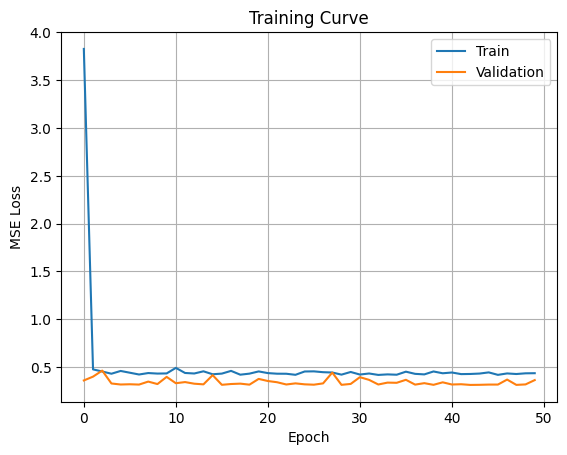

In [146]:
plt.figure()

plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.title("Training Curve")

plt.legend()
plt.grid()

plt.show()


In [147]:
model.eval()

predictions = []
targets = []

with torch.no_grad():

    for grid,target in val_loader:

        pred = model(grid)

        predictions.extend(pred.numpy())
        targets.extend(target.numpy())

predictions = np.array(predictions).flatten()
targets = np.array(targets).flatten()


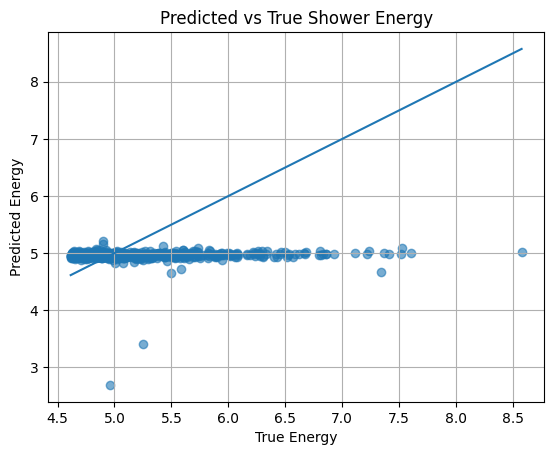

In [148]:
plt.figure()

plt.scatter(targets,predictions,alpha=0.6)

plt.xlabel("True Energy")
plt.ylabel("Predicted Energy")

plt.title("Predicted vs True Shower Energy")

plt.plot(
    [targets.min(),targets.max()],
    [targets.min(),targets.max()]
)

plt.grid()

plt.show()


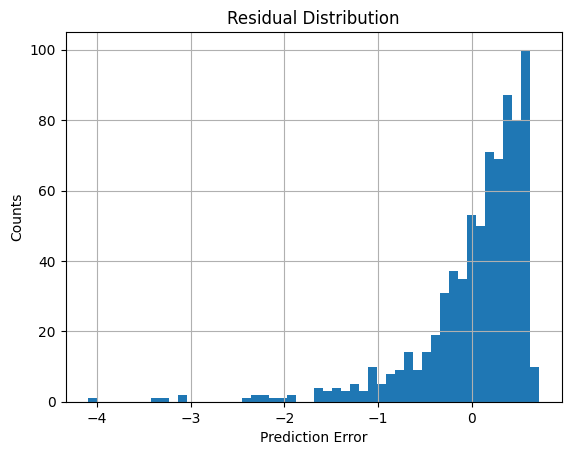

In [22]:
residuals = predictions - targets

plt.figure()

plt.hist(residuals,bins=50)

plt.xlabel("Prediction Error")
plt.ylabel("Counts")

plt.title("Residual Distribution")

plt.grid()

plt.show()
